<!--
  ============================================================================
  Section_D_time_complexity_analysis.ipynb  —  reproducibility notebook
  Section D of the Supplementary Materials
  ============================================================================
-->

<h1 align="center">Time Complexity Analysis for TAVIE-SSG</h1>

<p align="center">
  <b>Reproducibility for the time complexity analysis of Section D of the Supplementary Materials</b><br>
  <i>Runtime per ELBO iteration &middot; scaling in n at fixed p &middot; scaling in p at fixed n</i>
</p>

<p align="center">
  <img alt="Python" src="https://img.shields.io/badge/Python-3.9-3776AB?logo=python&logoColor=white">
  <img alt="Jupyter" src="https://img.shields.io/badge/Jupyter-Notebook-F37626?logo=jupyter&logoColor=white">
  <img alt="TAVIE" src="https://img.shields.io/badge/TAVIE-module-1E4C7E">
</p>

<p align="center">
  <a href="https://github.com/Roy-SR-007/TAVIE-SSG/blob/main/Section_D_time_complexity_analysis.ipynb"><img alt="nbviewer" src="https://img.shields.io/badge/render-nbviewer-F37726?logo=jupyter&logoColor=white"></a>
  <img alt="Data" src="https://img.shields.io/badge/data-simulated-005EA2">
</p>

---

### What this notebook does

This notebook measures how the per-iteration cost of a TAVIE-SSG fit grows with the sample
size $n$ and with the dimension $p$, and compares the measured growth against the
theoretical rates. Data are simulated from a Student's-$t$ Type I SSG model, a
**TAVIE-SSG** fit is timed, and the elapsed time is divided by the number of ELBO
iterations, so the reported quantity is the cost of a single iteration rather than of the
whole optimization. Each grid point is repeated 100 times, and the log&ndash;log slope of
mean runtime against $n$ or $p$ is fitted and compared with the reference curves.

| | Specification |
|:--|:--|
| **Model** | Student's-$t$ Type I SSG likelihood, `TAVIE_loc_scale(family="student", fit_intercept=True)` |
| **Truth and power** | $\nu = 5$, $\tau^{2}_{\mathrm{true}} = 1.0$, likelihood power $\alpha = 1.0$ |
| **Timed quantity** | wall-clock fit time divided by the number of ELBO iterations |
| **Scaling in $n$** | $n \in \{100, 200, 400, 800, 1600\}$ at fixed $p = 31$, 100 repetitions per grid point |
| **Scaling in $p$** | $p \in \{6, 11, 16, 21, 51, 81, 101\}$ at fixed $n = 1000$, 100 repetitions per grid point |
| **Dimension convention** | the plotted $p$ includes the intercept; the grids are specified as the $p-1$ columns of `X` |
| **Reference curves** | $\mathcal{O}(n)$ for the $n$ panel; $\mathcal{O}(p^{2})$ and $\mathcal{O}(p^{3})$ for the $p$ panel, each anchored at the first grid point |

> [!IMPORTANT]
> **To reproduce, run every cell in order, top to bottom.**

### Results generated in this notebook

| Main Manuscript | Supplementary Materials | Output file |
|:--:|:--:|:--|
| — | **Figure 11** | `tavie_scaling.pdf` |

All files are written to `results_time_complexity/`, which also holds the measured runtime
tables `tavie_scaling_n.csv` and `tavie_scaling_p.csv`.

In [1]:
# required imports
import numpy as np
from time import perf_counter
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from TAVIE import *

#### Note:

Depending on the machine configurations, the runtime results may vary. For obtaining the following results, a MacBook Air (M2) with 8GB of RAM has been used.

### Auxiliary Functions

In [3]:
def run_once(n: int, p: int, rep: int) -> float:
    np.random.seed(1000 * rep + n * 10 + p)

    X = np.random.normal(size=(n, p))
    beta_true = np.random.normal(size=p + 1)

    error = np.random.standard_t(df=df, size=n) / np.sqrt(tau2_true)
    y = beta_true[0] + X @ beta_true[1:] + error

    model = TAVIE_loc_scale(family="student", fit_intercept=True)

    t0 = perf_counter()
    model.fit(X, y, nu=df, alpha=alpha, verbose=False)
    niter = len(model.get_elbo())
    return (perf_counter() - t0)/niter

def fit_loglog_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    slope, intercept = np.polyfit(np.log(x), np.log(y), 1)
    return slope, intercept

def theoretical_curve_from_anchor(x, anchor_x, anchor_y, exponent):
    c = anchor_y / (anchor_x ** exponent)
    return c * (np.asarray(x) ** exponent)

### Scaling in $n$; Fixed $p$ (includes intercept), varying $n$

In [ ]:
def run_scaling_in_n(n_grid, p_fixed, n_rep):
    out = []
    for n in tqdm(n_grid, desc="Scaling in n"):
        times = []
        for rep in tqdm(range(n_rep), leave=False, desc=f"n={n}"):
            times.append(run_once(n, p_fixed, rep))

        times = np.array(times)
        out.append({
            "n": n,
            "p": p_fixed,
            "time_mean": times.mean(),
            "time_std": times.std(),
            "time_se": times.std() / np.sqrt(n_rep),
        })
    return pd.DataFrame(out)

n_rep = 100

df = 5
tau2_true = 1.0
alpha = 1.0

n_grid = [100, 200, 400, 800, 1600]
total_p = 31 # total_p = p_fixed + 1
p_fixed = 30

df_n = run_scaling_in_n(n_grid, p_fixed, n_rep)

slope_n, intercept_n = fit_loglog_slope(df_n["n"], df_n["time_mean"])

th_n = theoretical_curve_from_anchor(
    x=df_n["n"].values,
    anchor_x=df_n["n"].values[0],
    anchor_y=df_n["time_mean"].values[0],
    exponent=1.0,
)

df_n.to_csv("results_time_complexity/tavie_scaling_n.csv", index=False)

### Scaling in $p$ (includes intercept); Fixed $n$, varying $p$

In [ ]:
def run_scaling_in_p(p_grid, n_fixed, n_rep):
    out = []
    for p in tqdm(p_grid, desc="Scaling in p"):
        times = []
        for rep in tqdm(range(n_rep), leave=False, desc=f"p={p}"):
            times.append(run_once(n_fixed, p, rep))

        times = np.array(times)
        out.append({
            "n": n_fixed,
            "p": p,
            "time_mean": times.mean(),
            "time_std": times.std(),
            "time_se": times.std() / np.sqrt(n_rep),
        })
    return pd.DataFrame(out)

n_rep = 100

df = 5
tau2_true = 1.0
alpha = 1.0

total_p = [6, 11, 16, 21, 51, 81, 101] # total_p = p_grid + 1
p_grid = [5, 10, 15, 20, 50, 80, 100]
n_fixed = 1000

df_p = run_scaling_in_p(p_grid, n_fixed, n_rep)

slope_p, intercept_p = fit_loglog_slope(df_p["p"], df_p["time_mean"])

th_p2 = theoretical_curve_from_anchor(
    x=df_p["p"].values,
    anchor_x=df_p["p"].values[0],
    anchor_y=df_p["time_mean"].values[0],
    exponent=2.0,
)

th_p3 = theoretical_curve_from_anchor(
    x=df_p["p"].values,
    anchor_x=df_p["p"].values[0],
    anchor_y=df_p["time_mean"].values[0],
    exponent=3.0,
)

df_p.to_csv("results_time_complexity/tavie_scaling_p.csv", index=False)

In [4]:
df = 5
tau2_true = 1.0
alpha = 1.0

total_p_grid = [6, 11, 16, 21, 51, 81, 101] # total_p = p_grid + 1
p_grid = [5, 10, 15, 20, 50, 80, 100]
n_fixed = 1000

n_grid = [100, 200, 400, 800, 1600]
total_p_fixed = 31 # total_p = p_fixed + 1
p_fixed = 30

df_n = pd.read_csv("results_time_complexity/tavie_scaling_n_best.csv")
df_p = pd.read_csv("results_time_complexity/tavie_scaling_p_best.csv")

slope_n, intercept_n = fit_loglog_slope(df_n["n"], df_n["time_mean"])

th_n = theoretical_curve_from_anchor(
    x=df_n["n"].values,
    anchor_x=df_n["n"].values[0],
    anchor_y=df_n["time_mean"].values[0],
    exponent=1.0,
)

print("\nScaling in n:\n", df_n)
print(f"\nEstimated slope in n (p fixed): {slope_n:.3f}")
df_n.to_csv("results_time_complexity/tavie_scaling_n.csv", index=False)

slope_p, intercept_p = fit_loglog_slope(df_p["p"] + 1, df_p["time_mean"])

th_p2 = theoretical_curve_from_anchor(
    x=df_p["p"].values + 1,
    anchor_x=df_p["p"].values[0] + 1,
    anchor_y=df_p["time_mean"].values[0],
    exponent=2.0,
)

th_p3 = theoretical_curve_from_anchor(
    x=df_p["p"].values + 1,
    anchor_x=df_p["p"].values[0] + 1,
    anchor_y=df_p["time_mean"].values[0],
    exponent=3.0,
)

print("\nScaling in p:\n", df_p)
print(f"Estimated slope in p (n fixed): {slope_p:.3f}")
df_p.to_csv("results_time_complexity/tavie_scaling_p.csv", index=False)



Scaling in n:
       n   p  time_mean  time_std   time_se
0   100  30   0.000140  0.000034  0.000011
1   200  30   0.000157  0.000015  0.000005
2   400  30   0.000480  0.000147  0.000047
3   800  30   0.000877  0.000256  0.000081
4  1600  30   0.002371  0.002943  0.000931

Estimated slope in n (p fixed): 1.065

Scaling in p:
       n    p  time_mean  time_std   time_se
0  1000    5   0.000185  0.000049  0.000016
1  1000   10   0.000506  0.000171  0.000054
2  1000   15   0.002671  0.003793  0.001199
3  1000   20   0.001410  0.001023  0.000324
4  1000   50   0.213090  0.013729  0.004342
5  1000   80   0.476326  0.013010  0.004114
6  1000  100   0.493104  0.007095  0.002244
Estimated slope in p (n fixed): 3.139


### Plots: Figure 11 of Supplementary Materials

See: `results_time_complexity/tavie_scaling.pdf`

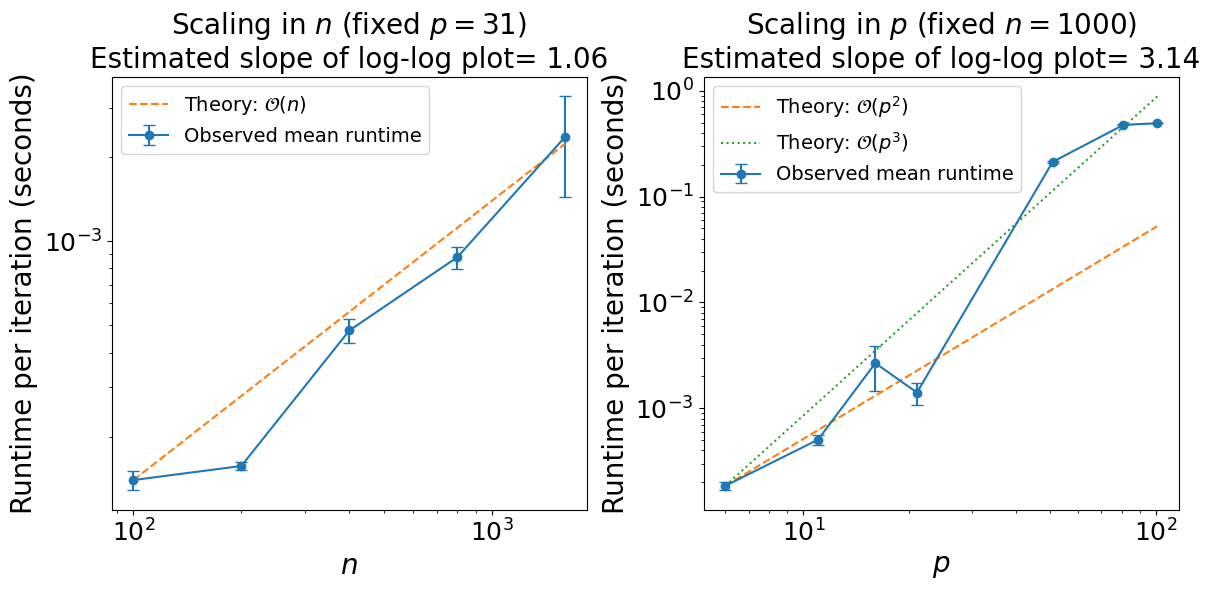

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax in axes:
    ax.tick_params(axis="both", which="both", labelsize=18)

# -------------------------
# Panel 1: scaling in n
# -------------------------
ax = axes[0]
ax.errorbar(
    df_n["n"],
    df_n["time_mean"],
    yerr=df_n["time_se"],
    fmt="o-",
    capsize=4,
    label="Observed mean runtime",
)
ax.plot(df_n["n"], th_n, "--", label=r"Theory: $\mathcal{O}(n)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$n$", fontsize=20)
ax.set_ylabel("Runtime per iteration (seconds)", fontsize=20)
ax.set_title(rf"Scaling in $n$ (fixed $p={p_fixed+1}$)" + "\n" + rf"Estimated slope of log-log plot= {slope_n:.2f}", fontsize=20)
ax.grid(False)
ax.legend(fontsize=14)

# -------------------------
# Panel 2: scaling in p
# -------------------------
ax = axes[1]
ax.errorbar(
    df_p["p"]+1,
    df_p["time_mean"],
    yerr=df_p["time_se"],
    fmt="o-",
    capsize=4,
    label="Observed mean runtime",
)
ax.plot(df_p["p"]+1, th_p2, "--", label=r"Theory: $\mathcal{O}(p^2)$")
ax.plot(df_p["p"]+1, th_p3, ":", label=r"Theory: $\mathcal{O}(p^3)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$p$", fontsize=20)
ax.set_ylabel("Runtime per iteration (seconds)", fontsize=20)
ax.set_title(rf"Scaling in $p$ (fixed $n={n_fixed}$)" + "\n" + rf"Estimated slope of log-log plot= {slope_p:.2f}", fontsize=20)
ax.grid(False)
ax.legend(fontsize=14)

plt.tight_layout()

plt.savefig("results_time_complexity/tavie_scaling.pdf", dpi=300, bbox_inches="tight")
plt.show()

